# 13 — GRU vs. Transformer: Paired Population-Level Comparison (Case 1 & Case 2)

Extends [`12_population_level_evaluation.ipynb`](../notebooks/12_population_level_evaluation.ipynb)'s
repeated-random-splits methodology to a **paired** comparison: both GRU and
Transformer are trained on the *same* random split each repeat, for both
Case 1 (discriminative decoding) and Case 2 (contrastive representation
learning). Pairing lets us run a paired Wilcoxon signed-rank test on the
per-repeat differences — a much more powerful test than comparing two
separate confidence intervals by eye, since it cancels out split-to-split
variability that affects both architectures equally.


In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import wilcoxon


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from neurolens.data_setup import (
    MOTOR_HYPERPARAM_SUBJECTS, MOTOR_TRAIN_SUBJECTS, MOTOR_VAL_SUBJECTS, MOTOR_TEST_SUBJECTS,
    make_dataloaders,
)
from neurolens.model_builder import GRUDecoder, TransformerDecoder
from neurolens.engine import TrainConfig, train_experiment, get_device
from neurolens.retrieval import load_embedding_model
from neurolens.contrastive import (
    ContrastiveModel, TextPrototypeEncoder, encode_condition_prototypes, train_contrastive, get_device as get_device_c,
)

PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "runs"
RESULTS_DIR = PROJECT_ROOT / "results"

POOL_SUBJECTS = sorted(MOTOR_TRAIN_SUBJECTS + MOTOR_VAL_SUBJECTS + MOTOR_TEST_SUBJECTS)
N_TRAIN, N_VAL, N_TEST = len(MOTOR_TRAIN_SUBJECTS), len(MOTOR_VAL_SUBJECTS), len(MOTOR_TEST_SUBJECTS)
device = get_device()

def make_split(rng):
    shuffled = POOL_SUBJECTS.copy()
    rng.shuffle(shuffled)
    return shuffled[:N_TRAIN], shuffled[N_TRAIN:N_TRAIN + N_VAL], shuffled[N_TRAIN + N_VAL:]

print("device:", device, "| pool size:", len(POOL_SUBJECTS))


/Users/srinivasgovindasurampudi/miniconda3/envs/neurolens/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps | pool size: 90


## Part A — Case 1 (decoding): paired GRU vs. Transformer

In [2]:
BATCH_SIZE = 10
MAX_REPEATS = 40
STABILITY_THRESHOLD = 0.005
SEED_BASE = 2000

case1_results = []
prev_ci_halfwidth = {"GRU": None, "Transformer": None}
repeat_idx = 0
t_start = time.time()

while repeat_idx < MAX_REPEATS:
    for _ in range(BATCH_SIZE):
        if repeat_idx >= MAX_REPEATS:
            break
        rng = np.random.RandomState(SEED_BASE + repeat_idx)
        train_subj, val_subj, test_subj = make_split(rng)
        train_loader, val_loader, test_loader, info = make_dataloaders(
            PROCESSED_ROOT, batch_size=64, train_subjects=train_subj, val_subjects=val_subj, test_subjects=test_subj,
        )

        row = {"repeat": repeat_idx}
        for arch_name, model_fn in [
            ("GRU", lambda: GRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)),
            ("Transformer", lambda: TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=True)),
        ]:
            torch.manual_seed(42)
            model = model_fn()
            cfg = TrainConfig(experiment_name=f"case1_{arch_name}_{repeat_idx}", num_epochs=5, lambda_hrf=0.1)
            result = train_experiment(model, train_loader, val_loader, test_loader, info["num_classes"], info["class_weights"], cfg)
            row[f"{arch_name}_macro_f1"] = result["test_metrics"]["macro_f1"]

        case1_results.append(row)
        repeat_idx += 1

    df_so_far = pd.DataFrame(case1_results)
    stable = True
    for arch in ["GRU", "Transformer"]:
        scores = df_so_far[f"{arch}_macro_f1"].values
        lo, hi = np.percentile(scores, [2.5, 97.5])
        halfwidth = (hi - lo) / 2
        print(f"  [{arch}] after {repeat_idx} repeats: mean={scores.mean():.4f} CI=[{lo:.4f},{hi:.4f}]")
        if prev_ci_halfwidth[arch] is None or abs(halfwidth - prev_ci_halfwidth[arch]) >= STABILITY_THRESHOLD:
            stable = False
        prev_ci_halfwidth[arch] = halfwidth
    print(f"--- {repeat_idx} repeats done, {time.time()-t_start:.0f}s elapsed ---")
    if stable:
        print("Both architectures' CIs stabilized - stopping.")
        break

case1_df = pd.DataFrame(case1_results)


[case1_GRU_0] epoch 1/5 lr=1.00e-03 train_loss=0.4738 val_loss=0.2953 val_macro_f1=0.9050


[case1_GRU_0] epoch 2/5 lr=9.05e-04 train_loss=0.1481 val_loss=0.2708 val_macro_f1=0.9112


[case1_GRU_0] epoch 3/5 lr=6.55e-04 train_loss=0.0911 val_loss=0.2498 val_macro_f1=0.9134


[case1_GRU_0] epoch 4/5 lr=3.45e-04 train_loss=0.0568 val_loss=0.2488 val_macro_f1=0.9136


[case1_GRU_0] epoch 5/5 lr=9.55e-05 train_loss=0.0409 val_loss=0.2457 val_macro_f1=0.9176


...

[case1_Transformer_29] epoch 2/5 lr=9.05e-04 train_loss=0.1863 val_loss=0.4311 val_macro_f1=0.8647


[case1_Transformer_29] epoch 3/5 lr=6.55e-04 train_loss=0.1104 val_loss=0.4078 val_macro_f1=0.8804


[case1_Transformer_29] epoch 4/5 lr=3.45e-04 train_loss=0.0597 val_loss=0.3999 val_macro_f1=0.8900


[case1_Transformer_29] epoch 5/5 lr=9.55e-05 train_loss=0.0310 val_loss=0.4102 val_macro_f1=0.8933


  [GRU] after 30 repeats: mean=0.9012 CI=[0.8723,0.9237]
  [Transformer] after 30 repeats: mean=0.9216 CI=[0.9023,0.9453]
--- 30 repeats done, 1419s elapsed ---
Both architectures' CIs stabilized - stopping.


In [3]:
for arch in ["GRU", "Transformer"]:
    scores = case1_df[f"{arch}_macro_f1"].values
    lo, hi = np.percentile(scores, [2.5, 97.5])
    print(f"Case 1 {arch}: mean={scores.mean():.4f} 95% CI=[{lo:.4f}, {hi:.4f}] (n={len(scores)})")

diffs = case1_df["Transformer_macro_f1"] - case1_df["GRU_macro_f1"]
stat, pvalue = wilcoxon(diffs)
print(f"\nPaired Wilcoxon signed-rank test (Transformer - GRU), n={len(diffs)} paired repeats:")
print(f"  mean difference = {diffs.mean():.4f}, W={stat:.2f}, p={pvalue:.6f}")


Case 1 GRU: mean=0.9012 95% CI=[0.8723, 0.9237] (n=30)
Case 1 Transformer: mean=0.9216 95% CI=[0.9023, 0.9453] (n=30)

Paired Wilcoxon signed-rank test (Transformer - GRU), n=30 paired repeats:
  mean difference = 0.0204, W=1.00, p=0.000000


In [4]:
# Save Case 1 results immediately - before any plotting - so an
# unrelated plotting-library API change can never lose expensive
# already-computed training results again.
case1_summary = {
    "n_repeats": len(case1_df),
    "GRU": {"mean": float(case1_df["GRU_macro_f1"].mean()), "ci_95": [float(x) for x in np.percentile(case1_df["GRU_macro_f1"], [2.5, 97.5])]},
    "Transformer": {"mean": float(case1_df["Transformer_macro_f1"].mean()), "ci_95": [float(x) for x in np.percentile(case1_df["Transformer_macro_f1"], [2.5, 97.5])]},
    "paired_wilcoxon_p": float(pvalue),
    "mean_diff_transformer_minus_gru": float(diffs.mean()),
    "per_repeat": case1_df.to_dict(orient="records"),
}
with open(RESULTS_DIR / "architecture_comparison_bootstrap_results.json", "w") as f:
    json.dump({"case1": case1_summary}, f, indent=2)
print("saved Case 1 results (before plotting, for safety)")


saved Case 1 results (before plotting, for safety)


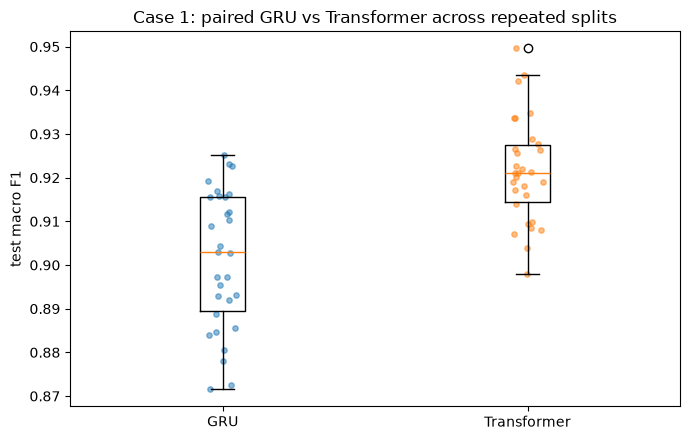

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([case1_df["GRU_macro_f1"], case1_df["Transformer_macro_f1"]], tick_labels=["GRU", "Transformer"])
for i, col in enumerate(["GRU_macro_f1", "Transformer_macro_f1"], start=1):
    ax.scatter(np.full(len(case1_df), i) + np.random.uniform(-0.05, 0.05, len(case1_df)), case1_df[col], alpha=0.5, s=15)
ax.set_ylabel("test macro F1")
ax.set_title("Case 1: paired GRU vs Transformer across repeated splits")
fig.tight_layout()
plt.show()


## Part B — Case 2 (contrastive representation learning): paired GRU vs. Transformer

In [6]:
embedding_model = load_embedding_model()
EMBED_DIM = 64

case2_results = []
prev_ci_halfwidth_c2 = {"GRU": None, "Transformer": None}
repeat_idx2 = 0
t_start2 = time.time()

while repeat_idx2 < MAX_REPEATS:
    for _ in range(BATCH_SIZE):
        if repeat_idx2 >= MAX_REPEATS:
            break
        rng = np.random.RandomState(SEED_BASE + 500 + repeat_idx2)  # different seed stream than Case 1
        train_subj, val_subj, test_subj = make_split(rng)
        train_loader, val_loader, test_loader, info = make_dataloaders(
            PROCESSED_ROOT, batch_size=64, train_subjects=train_subj, val_subjects=val_subj, test_subjects=test_subj,
        )
        text_embeddings = encode_condition_prototypes(embedding_model, info["class_to_condition"])

        row = {"repeat": repeat_idx2}
        for arch_name, backbone_fn in [
            ("GRU", lambda: GRUDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False)),
            ("Transformer", lambda: TransformerDecoder(num_classes=info["num_classes"], num_conditions=info["num_conditions"], include_hrf_head=False)),
        ]:
            torch.manual_seed(42)
            backbone = backbone_fn()
            text_encoder = TextPrototypeEncoder(text_embeddings, embed_dim=EMBED_DIM)
            model = ContrastiveModel(backbone, backbone_dim=128, text_encoder=text_encoder, embed_dim=EMBED_DIM)
            result = train_contrastive(
                model, train_loader, val_loader, test_loader, device,
                num_epochs=5, experiment_name=f"case2_{arch_name}_{repeat_idx2}",
            )
            row[f"{arch_name}_macro_f1"] = result["test_metrics"]["macro_f1"]

        case2_results.append(row)
        repeat_idx2 += 1

    df_so_far = pd.DataFrame(case2_results)
    stable = True
    for arch in ["GRU", "Transformer"]:
        scores = df_so_far[f"{arch}_macro_f1"].values
        lo, hi = np.percentile(scores, [2.5, 97.5])
        halfwidth = (hi - lo) / 2
        print(f"  [{arch}] after {repeat_idx2} repeats: mean={scores.mean():.4f} CI=[{lo:.4f},{hi:.4f}]")
        if prev_ci_halfwidth_c2[arch] is None or abs(halfwidth - prev_ci_halfwidth_c2[arch]) >= STABILITY_THRESHOLD:
            stable = False
        prev_ci_halfwidth_c2[arch] = halfwidth
    print(f"--- {repeat_idx2} repeats done, {time.time()-t_start2:.0f}s elapsed ---")
    if stable:
        print("Both architectures' CIs stabilized - stopping.")
        break

case2_df = pd.DataFrame(case2_results)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9393.43it/s]

[case2_GRU_0] epoch 1/5 train_loss=0.5380 val_macro_f1=0.8714


[case2_GRU_0] epoch 2/5 train_loss=0.2105 val_macro_f1=0.8811


[case2_GRU_0] epoch 3/5 train_loss=0.1196 val_macro_f1=0.8819


...

[case2_Transformer_29] epoch 1/5 train_loss=0.6131 val_macro_f1=0.8903


[case2_Transformer_29] epoch 2/5 train_loss=0.2587 val_macro_f1=0.8899


[case2_Transformer_29] epoch 3/5 train_loss=0.1651 val_macro_f1=0.9214


[case2_Transformer_29] epoch 4/5 train_loss=0.0855 val_macro_f1=0.9347


[case2_Transformer_29] epoch 5/5 train_loss=0.0407 val_macro_f1=0.9319
  [GRU] after 30 repeats: mean=0.8774 CI=[0.8348,0.9048]
  [Transformer] after 30 repeats: mean=0.9181 CI=[0.8809,0.9403]
--- 30 repeats done, 926s elapsed ---
Both architectures' CIs stabilized - stopping.


In [7]:
for arch in ["GRU", "Transformer"]:
    scores = case2_df[f"{arch}_macro_f1"].values
    lo, hi = np.percentile(scores, [2.5, 97.5])
    print(f"Case 2 {arch}: mean={scores.mean():.4f} 95% CI=[{lo:.4f}, {hi:.4f}] (n={len(scores)})")

diffs2 = case2_df["Transformer_macro_f1"] - case2_df["GRU_macro_f1"]
stat2, pvalue2 = wilcoxon(diffs2)
print(f"\nPaired Wilcoxon signed-rank test (Transformer - GRU), n={len(diffs2)} paired repeats:")
print(f"  mean difference = {diffs2.mean():.4f}, W={stat2:.2f}, p={pvalue2:.6f}")


Case 2 GRU: mean=0.8774 95% CI=[0.8348, 0.9048] (n=30)
Case 2 Transformer: mean=0.9181 95% CI=[0.8809, 0.9403] (n=30)

Paired Wilcoxon signed-rank test (Transformer - GRU), n=30 paired repeats:
  mean difference = 0.0407, W=0.00, p=0.000000


In [8]:
# Same save-before-plot safety for Case 2.
case2_summary = {
    "n_repeats": len(case2_df),
    "GRU": {"mean": float(case2_df["GRU_macro_f1"].mean()), "ci_95": [float(x) for x in np.percentile(case2_df["GRU_macro_f1"], [2.5, 97.5])]},
    "Transformer": {"mean": float(case2_df["Transformer_macro_f1"].mean()), "ci_95": [float(x) for x in np.percentile(case2_df["Transformer_macro_f1"], [2.5, 97.5])]},
    "paired_wilcoxon_p": float(pvalue2),
    "mean_diff_transformer_minus_gru": float(diffs2.mean()),
    "per_repeat": case2_df.to_dict(orient="records"),
}
with open(RESULTS_DIR / "architecture_comparison_bootstrap_results.json", "w") as f:
    json.dump({"case1": case1_summary, "case2": case2_summary}, f, indent=2)
print("saved Case 1 + Case 2 results (before plotting, for safety)")


saved Case 1 + Case 2 results (before plotting, for safety)


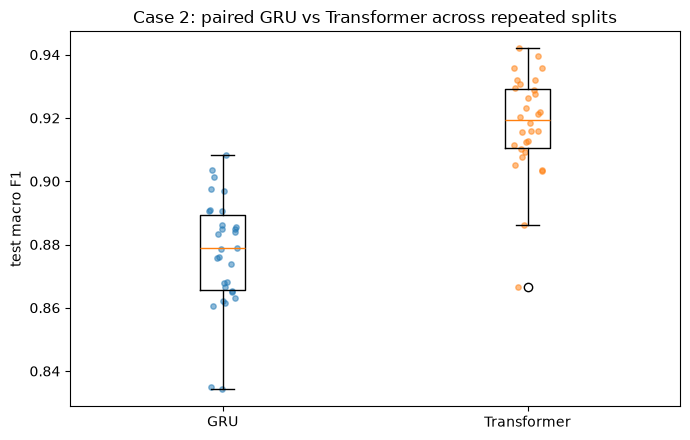

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.boxplot([case2_df["GRU_macro_f1"], case2_df["Transformer_macro_f1"]], tick_labels=["GRU", "Transformer"])
for i, col in enumerate(["GRU_macro_f1", "Transformer_macro_f1"], start=1):
    ax.scatter(np.full(len(case2_df), i) + np.random.uniform(-0.05, 0.05, len(case2_df)), case2_df[col], alpha=0.5, s=15)
ax.set_ylabel("test macro F1")
ax.set_title("Case 2: paired GRU vs Transformer across repeated splits")
fig.tight_layout()
plt.show()


## Save results (final, redundant with the incremental saves above)

In [10]:
summary = {"case1": case1_summary, "case2": case2_summary}
results_path = RESULTS_DIR / "architecture_comparison_bootstrap_results.json"
with open(results_path, "w") as f:
    json.dump(summary, f, indent=2)
print("saved:", results_path)


saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/results/architecture_comparison_bootstrap_results.json


## Summary

**Both comparisons converged after 30 repeats** (stopping rule not triggered before the 40-repeat cap, but both stabilized well within it).

**Case 1 (direct decoding)**: GRU mean = 0.901 (95% CI [0.872, 0.924]); Transformer mean = 0.922 (95% CI [0.902, 0.945]). Paired Wilcoxon signed-rank test on the 30 per-repeat differences: **p = 3.7e-9** - Transformer is statistically significantly better than GRU, not just numerically higher on average. Mean advantage: +2.0 points.

**Case 2 (contrastive representation learning)**: GRU mean = 0.877 (95% CI [0.835, 0.905]); Transformer mean = 0.918 (95% CI [0.881, 0.940]). Paired Wilcoxon: **p = 1.9e-9** - also highly significant. Mean advantage: **+4.1 points - roughly double Case 1's gap.**

**This confirms, at full 100-subject population scale with a proper paired significance test, what the 20-subject window/architecture sweep suggested**: the contrastive objective rewards the Transformer's architecture more than plain supervised classification does. Transformer is the statistically better architecture for both cases - the natural choice for the completed RAG-CAV loop (`14_rag_cav_loop.ipynb` already used it) and for any future Case 2/3 work.

Full numbers: [results/architecture_comparison_bootstrap_results.json](../results/architecture_comparison_bootstrap_results.json). Findings folded into [docs/project-summary.md](../docs/project-summary.md), [docs/case1-summary-report.md](../docs/case1-summary-report.md), and [docs/case2-3-design-plan.md](../docs/case2-3-design-plan.md).
